# EDA on the cleaned floorsheet data

Basic exploratory analysis before clustering: shape/dtypes, descriptive stats, distributions, outliers, daily activity, top symbols, and broker activity.

Load paths from `.env` and read the cleaned data.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv(Path("..") / ".env")

CLEAN_PATH = Path("..") / os.environ["CLEAN_FLOORSHEET_PATH"]

df = pd.read_parquet(CLEAN_PATH)
df.shape

(47346001, 8)

Quick look at dtypes and date coverage.

In [2]:
n_symbols = df["symbol"].nunique()
n_days = df["date"].nunique()
date_min, date_max = df["date"].min(), df["date"].max()

print(df.dtypes)
print()
print("unique symbols:", n_symbols)
print("trading days:", n_days)
print("date range:", date_min.date(), "to", date_max.date())

transaction            string
symbol                 string
buyer                  string
seller                 string
quantity              float64
rate                  float64
amount                float64
date           datetime64[us]
dtype: object

unique symbols: 516
trading days: 561
date range: 2024-01-01 to 2026-07-21


Descriptive stats for the numeric columns.

In [3]:
numeric_cols = ["quantity", "rate", "amount"]
stats = df[numeric_cols].describe()
stats

,quantity,rate,amount
count,4.734600e+07,4.734600e+07,4.734600e+07
mean,2.000592e+02,6.476396e+02,8.490937e+04
std,2.191892e+03,7.380787e+02,4.330643e+05
min,1.000000e+00,6.530000e+00,8.600000e+00
25%,1.000000e+01,3.240000e+02,8.230000e+03
50%,5.000000e+01,5.180000e+02,2.500000e+04
75%,1.700000e+02,7.750000e+02,8.111000e+04
max,1.000000e+06,5.680580e+04,2.359193e+08


Mean is way above the median for all three columns, so check skewness directly instead of guessing from `describe()` alone.

In [4]:
skewness = df[numeric_cols].skew()
skewness

quantity    217.126505
rate         24.203935
amount      139.452683
dtype: float64

All three are heavily right-skewed, so plot histograms on a log x-axis instead of linear (linear would just show one tall bar near zero).

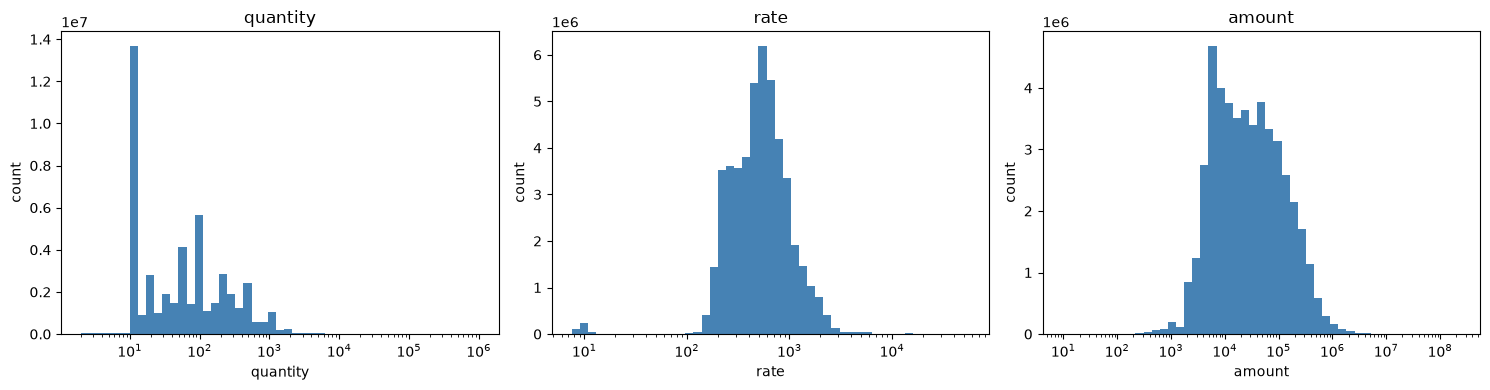

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    bins = np.logspace(np.log10(df[col].min() + 1), np.log10(df[col].max()), 50)
    ax.hist(df[col], bins=bins, color="steelblue")
    ax.set_xscale("log")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")

fig.tight_layout()
plt.show()

Flag outliers with the standard IQR rule (1.5x IQR above Q3) on `amount` — how many trades look unusually large?

In [6]:
q1, q3 = df["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

n_outliers = (df["amount"] > upper_bound).sum()
pct_outliers = n_outliers / len(df) * 100

print(f"upper bound: {upper_bound:,.0f}")
print(f"amount outliers: {n_outliers:,} ({pct_outliers:.2f}% of trades)")

upper bound: 190,430
amount outliers: 5,162,038 (10.90% of trades)


Daily trading activity: number of trades and total turnover per day.

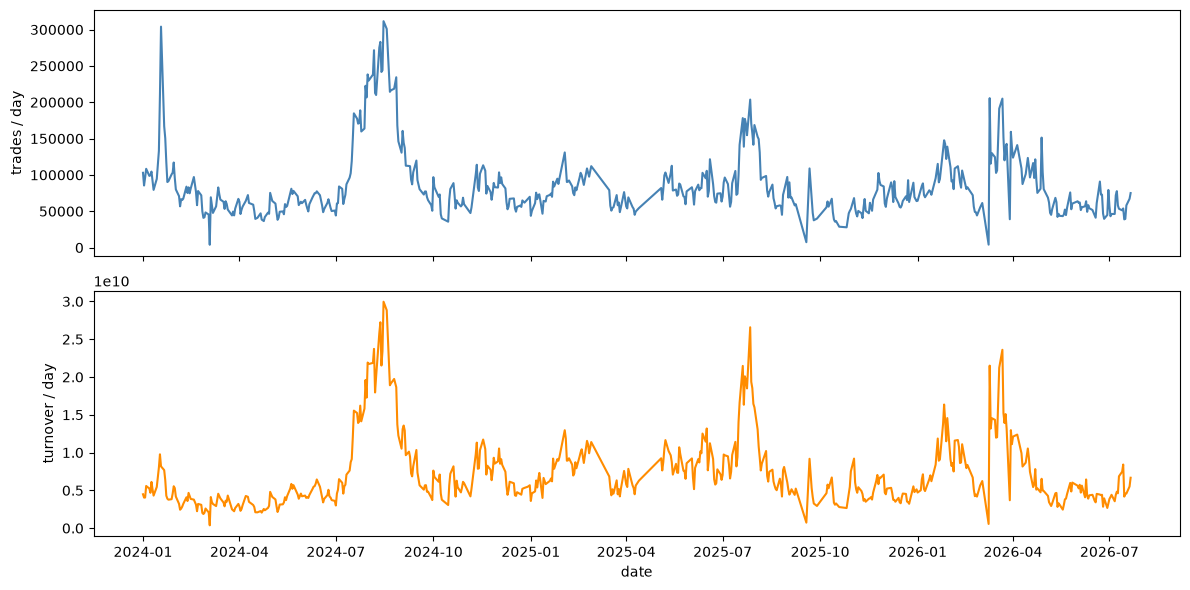

In [7]:
daily = df.groupby("date").agg(
    n_trades=("transaction", "count"),
    turnover=("amount", "sum"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(daily["date"], daily["n_trades"], color="steelblue")
axes[0].set_ylabel("trades / day")
axes[1].plot(daily["date"], daily["turnover"], color="darkorange")
axes[1].set_ylabel("turnover / day")
axes[1].set_xlabel("date")
fig.tight_layout()
plt.show()

Top 15 symbols by total turnover.

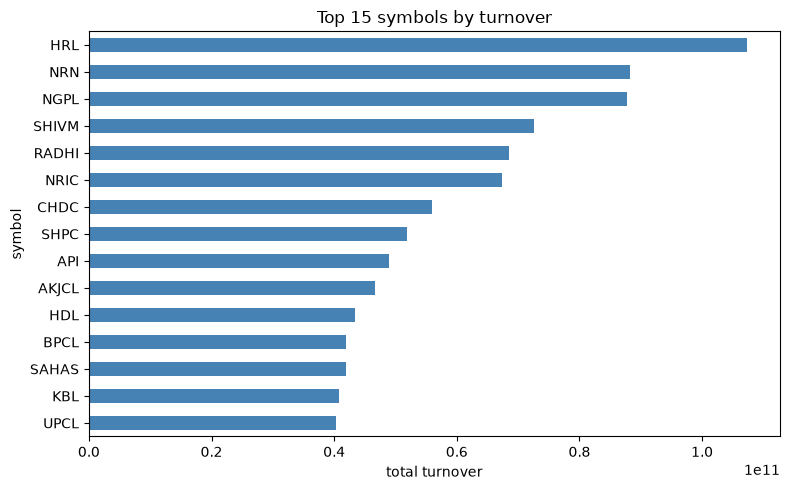

In [8]:
top_turnover = (
    df.groupby("symbol")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
top_turnover.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("total turnover")
ax.set_title("Top 15 symbols by turnover")
fig.tight_layout()
plt.show()

Top 15 symbols by number of trades — worth comparing against the turnover ranking above.

In [9]:
top_trade_count = (
    df.groupby("symbol")["transaction"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

overlap = set(top_turnover.index) & set(top_trade_count.index)
print(f"symbols in both top-15 lists: {len(overlap)}")
top_trade_count

symbols in both top-15 lists: 7


symbol
HRL      1650611
SONA      613729
NIFRA     586134
NGPL      568378
UPPER     544487
SHIVM     534684
API       532155
KBL       502244
HDL       446351
HDHPC     438617
HBL       431594
RNLI      426117
SAHAS     423878
CLI       418819
AHPC      409660
Name: transaction, dtype: int64

Most active brokers, counting both buy-side and sell-side activity.

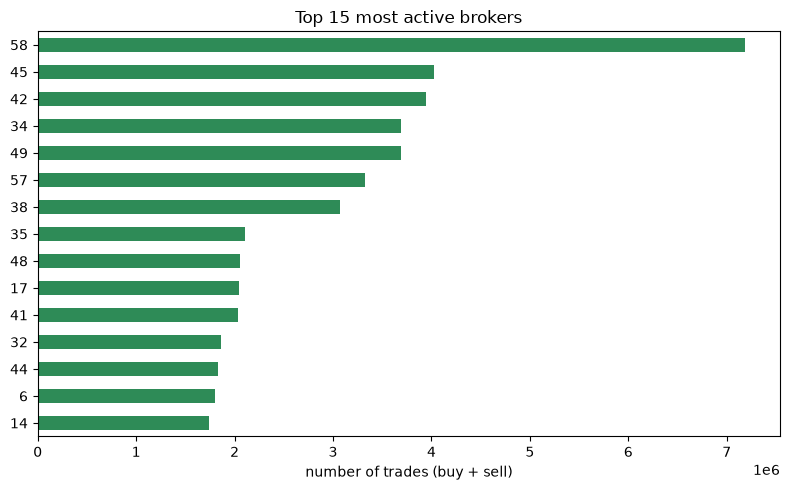

In [10]:
broker_activity = pd.concat([df["buyer"], df["seller"]]).value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
broker_activity.sort_values().plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("number of trades (buy + sell)")
ax.set_title("Top 15 most active brokers")
fig.tight_layout()
plt.show()

Correlation between quantity, rate, and amount.

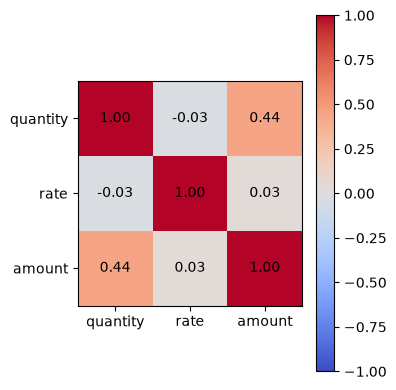

In [11]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)), numeric_cols)
ax.set_yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
fig.tight_layout()
plt.show()

## Summary

- `quantity`, `rate`, and `amount` are all heavily right-skewed — a small number of large trades dominate the totals, so any downstream model should use log-scaled or robust-scaled features.
- A meaningful share of trades sit above the IQR outlier bound on `amount` — these look like real large block trades rather than data errors, worth keeping but flagging as a feature.
- Turnover and trade count are dominated by a small set of symbols and brokers, which lines up with typical exchange concentration and is a useful signal for clustering.